A fintech company provides instant personal loans through a mobile application.

To reduce risk, the company wants an AI-based decision system that predicts whether a loan should be Approved or Rejected.

- Challenges:
    - Customer data is not linearly separable
    - Simple linear rules fail
    - Decision boundaries may be curved or complex
    - The solution must be interactive and deployable

You are hired as a Machine Learning Engineer to build and deploy this system.
 
1. Load the dataset and study applicant attributes such as:
    - Applicant income
    - Loan amount
    - Credit history
    - Employment status
2. Identify features that may influence loan approval.
3. Build three different SVM models using:
    - Linear kernel
    - Polynomial kernel
    - RBF kernel
4. Train each model and evaluate performance using:
    - Accuracy
    - Precision / Recall
5. Compare results and identify:
    - Which kernel handles non-linear patterns better
    - Which kernel generalizes best on unseen data
6. Analyze misclassifications:
    - How many eligible customers were rejected?
    - How many risky customers were approved?
7. Answer:
    - Is it worse to reject a genuine customer or approve a risky one?
    - Which metric matters most in this business scenario?
 

In [112]:
import numpy as numpy
import pandas as pd

df = pd.read_csv('train.csv')

In [113]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [114]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [115]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [116]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [117]:
# Handling missing values 
df['Gender'].fillna(df['Gender'].mode()[0], inplace = True)
df['Married'].fillna(df['Married'].mode()[0], inplace = True)
df['Dependents'].fillna(df['Dependents'].mode()[0], inplace = True)
df['Self_Employed'].fillna(df['Self_Employed'].mode()[0], inplace = True)
df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace = True)
df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median(), inplace = True)
df['Credit_History'].fillna(df['Credit_History'].median(), inplace = True)


C:\Users\rakes\AppData\Local\Temp\ipykernel_3608\3934313320.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Gender'].fillna(df['Gender'].mode()[0], inplace = True)
C:\Users\rakes\AppData\Local\Temp\ipykernel_3608\3934313320.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

In [118]:
df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [119]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             614 non-null    object 
 2   Married            614 non-null    object 
 3   Dependents         614 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      614 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         614 non-null    float64
 9   Loan_Amount_Term   614 non-null    float64
 10  Credit_History     614 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [120]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [121]:
# Encode categorical variables
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
categorical_columns = ['Self_Employed', 'Loan_Status']

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

In [122]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,0,5849,0.0,128.0,360.0,1.0,Urban,1
1,LP001003,Male,Yes,1,Graduate,0,4583,1508.0,128.0,360.0,1.0,Rural,0
2,LP001005,Male,Yes,0,Graduate,1,3000,0.0,66.0,360.0,1.0,Urban,1
3,LP001006,Male,Yes,0,Not Graduate,0,2583,2358.0,120.0,360.0,1.0,Urban,1
4,LP001008,Male,No,0,Graduate,0,6000,0.0,141.0,360.0,1.0,Urban,1


In [123]:
df.duplicated().sum()

np.int64(0)

In [124]:
X = df[['ApplicantIncome', 'LoanAmount', 'Credit_History', 'Self_Employed']].values
y = df['Loan_Status'].values

In [125]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

### Standardize the features

In [126]:

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Train the Data

In [127]:
from sklearn.svm import SVC

svm_linear = SVC(kernel='linear', C=1)
svm_linear.fit(X_train, y_train)


,C,1
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


# Test DataSet

### Load Dataset

In [128]:
dd = pd.read_csv('test_TN.csv')

In [129]:
dd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 367 entries, 0 to 366
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            367 non-null    object 
 1   Gender             356 non-null    object 
 2   Married            367 non-null    object 
 3   Dependents         357 non-null    object 
 4   Education          367 non-null    object 
 5   Self_Employed      344 non-null    object 
 6   ApplicantIncome    367 non-null    int64  
 7   CoapplicantIncome  367 non-null    int64  
 8   LoanAmount         362 non-null    float64
 9   Loan_Amount_Term   361 non-null    float64
 10  Credit_History     338 non-null    float64
 11  Property_Area      367 non-null    object 
dtypes: float64(3), int64(2), object(7)
memory usage: 34.5+ KB


In [130]:
dd.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban


In [131]:
dd.isnull().sum()

Loan_ID               0
Gender               11
Married               0
Dependents           10
Education             0
Self_Employed        23
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            5
Loan_Amount_Term      6
Credit_History       29
Property_Area         0
dtype: int64

In [132]:
# Handling missing values 

dd['Self_Employed'].fillna(dd['Self_Employed'].mode()[0], inplace = True)
dd['LoanAmount'].fillna(dd['LoanAmount'].median(), inplace = True)
dd['Credit_History'].fillna(dd['Credit_History'].median(), inplace = True)


C:\Users\rakes\AppData\Local\Temp\ipykernel_3608\3103902268.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dd['Self_Employed'].fillna(dd['Self_Employed'].mode()[0], inplace = True)
C:\Users\rakes\AppData\Local\Temp\ipykernel_3608\3103902268.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always beha

In [133]:
dd.isnull().sum()

Loan_ID               0
Gender               11
Married               0
Dependents           10
Education             0
Self_Employed         0
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            0
Loan_Amount_Term      6
Credit_History        0
Property_Area         0
dtype: int64

In [134]:
# Encode categorical variables
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
categorical_columns = ['Self_Employed']

for col in categorical_columns:
    dd[col] = le.fit_transform(dd[col])

In [166]:

X_new = dd[['ApplicantIncome', 'LoanAmount', 'Credit_History', 'Self_Employed']].values

In [167]:
X_new_scaled = scaler.transform(X_new)

### Linear Kernal

In [168]:
# Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Train
from sklearn.svm import SVC

svm_linear1 = SVC(kernel='linear', C=1)
svm_linear1.fit(X_train_scaled, y_train)

# Predict new dataset
X_new = dd[['ApplicantIncome', 'LoanAmount', 'Credit_History', 'Self_Employed']]
X_new_scaled = scaler.transform(X_new)

pred_linear = svm_linear1.predict(X_new_scaled)
print(pred_linear)


[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


c:\Users\rakes\anaconda31\envs\Himaenv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [169]:
# from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# print("Accuracy:", accuracy_score(y_test, y_pred_linear))
# print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_linear))

### Linear Kernal

In [ ]:
y_pred_linear = svm_linear.predict(X_test)

In [ ]:
# Accuracy
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
accuracy_linear = accuracy_score(y_test, y_pred_linear)
print(f"Accuracy (Linear Kernel): {accuracy_linear:.2f}")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_linear))


Accuracy (Linear Kernel): 0.77
Confusion Matrix:
 [[ 7 14]
 [ 0 41]]


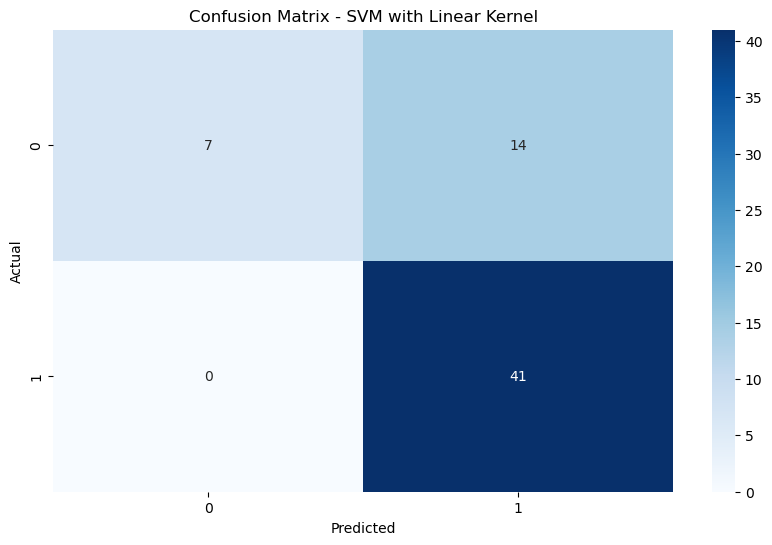

In [ ]:
# Visualization of Decision Boundaries (2D Example)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_linear), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - SVM with Linear Kernel')
plt.show()

### OutLiers

In [ ]:
Q1 = df['ApplicantIncome'].quantile(0.25)
Q3 = df['ApplicantIncome'].quantile(0.75)

IQR = Q3 - Q1

df_clean = df[(df['ApplicantIncome'] >= Q1 - 1.5*IQR) &
              (df['ApplicantIncome'] <= Q3 + 1.5*IQR)]

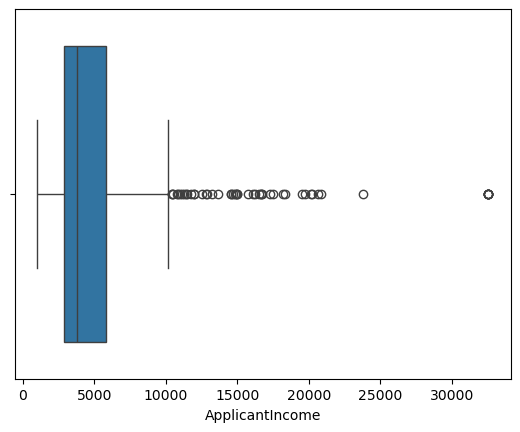

In [ ]:
lower = df['ApplicantIncome'].quantile(0.01)
upper = df['ApplicantIncome'].quantile(0.99)

df['ApplicantIncome'] = df['ApplicantIncome'].clip(lower, upper)

sns.boxplot(x=df['ApplicantIncome'])
plt.show()


#### Poly Kernal

In [ ]:
# Train SVM with Polynomial Kernel
svm_poly = SVC(kernel='poly', degree=3, C=1)
svm_poly.fit(X_train, y_train)


,C,1
,kernel,'poly'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [ ]:
y_pred_poly = svm_poly.predict(X_test)

In [ ]:
# Accuracy
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
accuracy_poly = accuracy_score(y_test, y_pred_poly)
print(f"Accuracy (Polynomial Kernel): {accuracy_poly:.2f}") 
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_poly))

Accuracy (Polynomial Kernel): 0.66
Confusion Matrix:
 [[ 0 21]
 [ 0 41]]


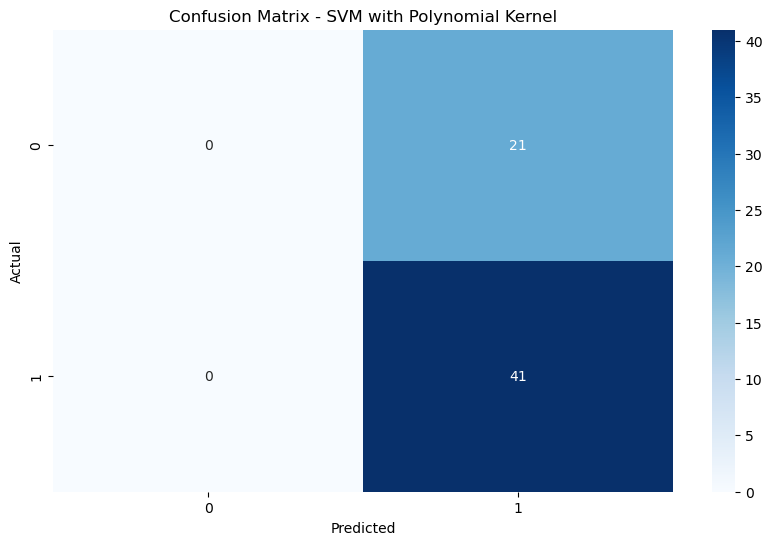

In [ ]:
# Visualization of Decision Boundaries

from sklearn.metrics import confusion_matrix 
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_poly), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - SVM with Polynomial Kernel')
plt.show()

### RBF Kernel

In [ ]:
# Train SVM with RBF Kernel
svm_rbf = SVC(kernel='rbf', C=1, gamma='scale')
svm_rbf.fit(X_train, y_train)
y_pred_rbf = svm_rbf.predict(X_test)

In [ ]:
# Accuracy
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
accuracy_rbf = accuracy_score(y_test, y_pred_rbf)
print(f"Accuracy (RBF Kernel): {accuracy_rbf:.2f}") 
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rbf))

Accuracy (RBF Kernel): 0.66
Confusion Matrix:
 [[ 0 21]
 [ 0 41]]


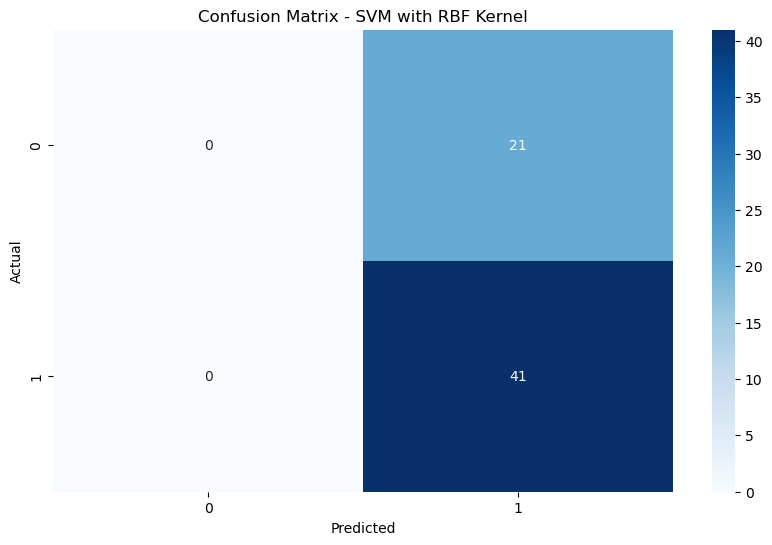

In [ ]:
# Visualization of Decision Boundaries (2D Example)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_rbf), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - SVM with RBF Kernel')
plt.show()

# Streamlit UI Design (Student Instructions)
1. 1️⃣ App Title & Description
    - Title: “Smart Loan Approval System”
    - Short description explaining:
        - “This system uses Support Vector Machines to predict loan approval.”
2. 2️⃣ Input Section (Sidebar or Main Panel)
    User should enter:
    - Applicant Income (number input)
    - Loan Amount (number input)
    - Credit History (Yes / No)
    - Employment Status (dropdown)
    - Property Area (dropdown)
3. 3️⃣ Model Selection (Important)
    - Radio button:
    - Linear SVM
    - Polynomial SVM
    - RBF SVM
This tests kernel understanding.
4. 4️⃣ Prediction Button
    - Button: “Check Loan Eligibility”
5. 5️⃣ Output Section (Main Result)
    Display clearly:
    - ✅ Loan Approved (Green highlight)
    - ❌ Loan Rejected (Red highlight)

    Optional (Bonus):
    - Confidence score
    - Kernel used
6. 6️⃣ Business Explanation (VERY IMPORTANT)
Display a short explanation:
“Based on credit history and income pattern, the applicant is likely / unlikely to repay the loan.”
 